First, let's import the necessary libraries: `cv2` for OpenCV operations and `numpy` for array manipulation. We'll also use `matplotlib` for displaying the images in Colab.

Image loaded successfully from /content/image 2.jpg and displayed.


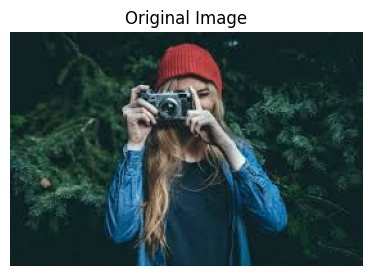

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image specified by the user
image_path = '/content/image 2.jpg'
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}. Please ensure the file exists.")
else:
    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    # cv2.imread loads images in BGR format, matplotlib expects RGB
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    print(f'Image loaded successfully from {image_path} and displayed.')

Now, we'll define three points on the original image and their corresponding desired positions in the transformed image. These three points are sufficient to define a 2D affine transformation.

In [2]:
# Get image dimensions
rows, cols, ch = image.shape

# Define 3 points on the original image (source points)
# For our white square, let's pick corners for clear transformation visualization
# Top-left corner of the square: (100, 50)
# Top-right corner of the square: (300, 50)
# Bottom-left corner of the square: (100, 250)
pts1 = np.float32([[100, 50], [300, 50], [100, 250]])

# Define 3 corresponding points on the destination image (destination points)
# Let's make it skew and scale it a bit
# New top-left
# New top-right
# New bottom-left
pts2 = np.float32([[50, 100], [350, 70], [150, 280]])

print(f"Source points: {pts1}")
print(f"Destination points: {pts2}")

Source points: [[100.  50.]
 [300.  50.]
 [100. 250.]]
Destination points: [[ 50. 100.]
 [350.  70.]
 [150. 280.]]


Next, we calculate the affine transformation matrix using `cv2.getAffineTransform` and then apply it to the image using `cv2.warpAffine`.

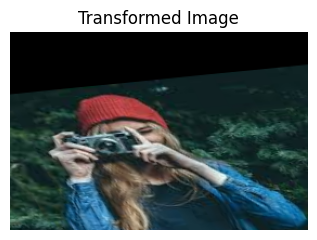

Affine transformation applied and result displayed.


In [3]:
# Get the affine transformation matrix
M = cv2.getAffineTransform(pts1, pts2)

# Apply the affine transformation to the image
# The third argument is the size of the output image (width, height)
transformed_image = cv2.warpAffine(image, M, (cols, rows))

# Display the transformed image alongside the original
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(transformed_image, cv2.COLOR_BGR2RGB))
plt.title('Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

print('Affine transformation applied and result displayed.')